## Full Name and Student IDS: 
### Selman Turan Toker 150220330
### Abdullah Aydoğan 150230731
### M. Burak Korkmaz 150220326

# Energy Mix Optimization using GA and PSO

This notebook implements and compares Genetic Algorithm (GA) and Particle Swarm Optimization (PSO)
for optimizing the energy mix of a country (Germany and France) based on 2022 data.
The objectives are to minimize electricity price increase and CO2 emissions, while maximizing
the renewable energy share, subject to various constraints.

In [1]:
import pandas as pd
import numpy as np
import random
import os
import time
import matplotlib.pyplot as plt

## 1. Constants and Configuration

In [2]:
# GA Parameters
POPULATION_SIZE_GA = 200
MAX_GENERATIONS_GA = 300
MUTATION_RATE_GA = 0.08
CROSSOVER_RATE_GA = 0.85

# PSO Parameters
NUM_PARTICLES_PSO = 100
MAX_ITER_PSO = 300
W_PSO = 0.5
C1_PSO = 1.5
C2_PSO = 1.5

# Objective Function Weights
ALPHA = 2.0
BETA = 0.8
GAMMA = 0.1

# Constraints
TARGET_PRICE_INCREASE_MAX = 1.12
TARGET_EMISSION_REDUCTION_MIN = 0.95

# Share Change Constraints 
MAX_RELATIVE_CHANGE_NORMAL = 0.30      
MAX_ABSOLUTE_CHANGE_PUNITS_NORMAL = 0.015 
ABSOLUTE_CAP_FOR_NEAR_ZERO_SHARES = 0.015 

PENALTY_WEIGHT_SHARE_CHANGE_NORMAL = 5000000 
PENALTY_WEIGHT_ZERO_CAP_EXCEED_SPECIFIC = PENALTY_WEIGHT_SHARE_CHANGE_NORMAL * 10 
ZERO_CAP_EXCEED_PENALTY_EXPONENT = 2.0 
NORMAL_SHARE_CHANGE_PENALTY_EXPONENT = 2.0 

PENALTY_WEIGHT_CONSTRAINTS = 35000

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

## 2. Data Loading and Preparation Function

In [3]:
def load_country_data(df_full, country_code_filter, year_filter):
    country_data = df_full[(df_full['country_code'] == country_code_filter) & (df_full['YEAR'] == year_filter)]
    if country_data.empty:
        print(f"Error: No data found for {country_code_filter} in year {year_filter}.")
        return None
    latest_year_data_series = country_data.iloc[0]
    x0_val = latest_year_data_series['AvgHouseholdPrice_Euro_per_kWh']
    y0_percent_val = latest_year_data_series['RenewableShare_Percent']
    y0_val = y0_percent_val / 100.0
    z0_val = latest_year_data_series['CO2_Emissions_Electricity_Tonne']
    T0_val = latest_year_data_series['TotalProduction_GWh']

    print(f"\nInitial Values ({country_code_filter} - {year_filter}):")
    print(f"  x0 (Avg. Electricity Price): {x0_val:.4f} Euro/kWh")
    print(f"  y0 (Renewable Share): {y0_val:.4f} ({y0_percent_val:.2f}%)")
    print(f"  z0 (Total CO2 Emission): {z0_val:,.0f} Tonne")
    print(f"  T0 (Total Production): {T0_val:,.0f} GWh")

    excluded_general_share_cols = ['RenewableShare_Percent', 'Fossil_energy_Share_Percent', 'Renewables_and_biofuels_Share_Percent']
    excluded_specific_share_cols = ['Batteries_Share_Percent']
    all_excluded_share_cols = excluded_general_share_cols + excluded_specific_share_cols
    share_cols_list = [col for col in df_full.columns if col.endswith('_Share_Percent') and col not in all_excluded_share_cols]
    
    initial_shares_d = {col: latest_year_data_series.get(col, 0) / 100.0 for col in share_cols_list if pd.notna(latest_year_data_series.get(col))}
    for col in share_cols_list:
        if col not in initial_shares_d: initial_shares_d[col] = 0.0
    num_decision_vars = len(share_cols_list)
    print(f"  {num_decision_vars} energy source shares found (Battery EXCLUDED).")
    if not share_cols_list:
        print(f"Error: No share columns identified for {country_code_filter}.")
        return None
    return x0_val, y0_val, z0_val, T0_val, initial_shares_d, share_cols_list, num_decision_vars

## 3. Cost Data and Definitions

In [4]:
default_op_cost = 0.15 
unit_costs_euro_per_kwh_DE = {
    'Solar_photovoltaic_Share_Percent': 0.050, 'Wind_Share_Percent': 0.065, 'Bioenergy_Share_Percent': 0.12,
    'Biogases_Share_Percent': 0.14, 'Hydro_Share_Percent': 0.050, 'Geothermal_Share_Percent': 0.15,
    'Renewable_municipal_waste_Share_Percent': 0.085, 'Other_liquid_biofuels_Share_Percent': 0.25,
    'Primary_solid_biofuels_Share_Percent': 0.12, 'Natural_gas_Share_Percent': 0.10,
    'Lignite_Share_Percent': 0.08, 'Anthracite_Share_Percent': 0.09, 'Other_bituminous_coal_Share_Percent': 0.09,
    'Coking_coal_Share_Percent': 0.09, 'Brown_coal_briquettes_Share_Percent': 0.08,
    'Coke_oven_coke_Share_Percent': 0.09, 'Nuclear_heat_Share_Percent': 0.045, 'Fuel_oil_Share_Percent': 0.18,
    'Gas_oil_and_diesel_oil_(excluding_biofuel_portion)_Share_Percent': 0.20,
    'Liquefied_petroleum_gases_Share_Percent': 0.15,
    'Other_oil_products_n.e.c._Share_Percent': 0.20, 'Other_oil_products_nec_Share_Percent': 0.20,
    'Petroleum_coke_Share_Percent': 0.10, 'Blast_furnace_gas_Share_Percent': 0.035,
    'Coke_oven_gas_Share_Percent': 0.035, 'Manufactured_gases_Share_Percent': 0.055,
    'Industrial_waste_(non-renewable)_Share_Percent': 0.065, 'Non-renewable_municipal_waste_Share_Percent': 0.065,
    'Other_recovered_gases_Share_Percent': 0.045, 'Refinery_gas_Share_Percent': 0.045,
    'Other_fuels_n.e.c._Share_Percent': 0.10, 'Other_fuels_nec_Share_Percent': 0.10,
    'Pumped_hydro_power_Share_Percent': 0.03,
    "Tide,_wave,_ocean_Share_Percent": 0.20
}
unit_costs_euro_per_kwh_FR = {
    'Solar_photovoltaic_Share_Percent': 0.045, 'Wind_Share_Percent': 0.046, 
    'Nuclear_heat_Share_Percent': 0.060, 'Natural_gas_Share_Percent': 0.120, 
    'Hydro_Share_Percent': 0.055, 'Bioenergy_Share_Percent': 0.100, 
    'Biogases_Share_Percent': 0.120, 'Primary_solid_biofuels_Share_Percent': 0.110,
    'Other_liquid_biofuels_Share_Percent': 0.200,  'Renewable_municipal_waste_Share_Percent': 0.090,
    'Geothermal_Share_Percent': 0.052, 'Anthracite_Share_Percent': 0.150, 
    'Lignite_Share_Percent': 0.150, 'Other_bituminous_coal_Share_Percent': 0.150, 
    'Coking_coal_Share_Percent': 0.150, 'Brown_coal_briquettes_Share_Percent': 0.150, 
    'Coke_oven_coke_Share_Percent': 0.150, 'Fuel_oil_Share_Percent': 0.200, 
    'Gas_oil_and_diesel_oil_(excluding_biofuel_portion)_Share_Percent': 0.200,
    'Liquefied_petroleum_gases_Share_Percent': 0.160, 
    'Other_oil_products_n.e.c._Share_Percent': 0.220, 'Other_oil_products_nec_Share_Percent': 0.220,
    'Petroleum_coke_Share_Percent': 0.120, 'Blast_furnace_gas_Share_Percent': 0.040, 
    'Coke_oven_gas_Share_Percent': 0.040, 'Manufactured_gases_Share_Percent': 0.060, 
    'Industrial_waste_(non-renewable)_Share_Percent': 0.070, 
    'Other_recovered_gases_Share_Percent': 0.050, 'Refinery_gas_Share_Percent': 0.050, 
    'Other_fuels_n.e.c._Share_Percent': 0.150, 'Other_fuels_nec_Share_Percent': 0.150,
    'Pumped_hydro_power_Share_Percent': 0.030, "Tide,_wave,_ocean_Share_Percent": 0.250
}

installation_costs_euro_per_kwh_increase_SHARED = {}
HIGH_INSTALL_COST = 30.0
def calculate_amortized_capex(capex_eur_per_kw, cap_factor, lt_years):
    if cap_factor <= 0 or lt_years <= 0: return HIGH_INSTALL_COST
    return (capex_eur_per_kw ) / (cap_factor * 8760 * lt_years)
installation_costs_euro_per_kwh_increase_SHARED.update({
    'Solar_photovoltaic_Share_Percent': calculate_amortized_capex(950, 0.10, 25),
    'Wind_Share_Percent': calculate_amortized_capex(2000, 0.21, 25),'Bioenergy_Share_Percent': calculate_amortized_capex(5000, 0.50, 18),
    'Biogases_Share_Percent': calculate_amortized_capex(5500, 0.50, 18),'Primary_solid_biofuels_Share_Percent': calculate_amortized_capex(5000, 0.50, 18),
    'Renewable_municipal_waste_Share_Percent': calculate_amortized_capex(5000, 0.50, 18),'Non-renewable_municipal_waste_Share_Percent': calculate_amortized_capex(5000, 0.50, 18),
    'Hydro_Share_Percent': calculate_amortized_capex(6500, 0.25, 35),'Geothermal_Share_Percent': calculate_amortized_capex(9500, 0.45, 25),
    'Other_liquid_biofuels_Share_Percent': calculate_amortized_capex(7500, 0.30, 15),'Pumped_hydro_power_Share_Percent': calculate_amortized_capex(5000, 0.07, 40),
    'Natural_gas_Share_Percent': calculate_amortized_capex(1200, 0.38, 30),'Nuclear_heat_Share_Percent': calculate_amortized_capex(10000, 0.90, 40),
    "Tide,_wave,_ocean_Share_Percent": calculate_amortized_capex(7000, 0.30, 25),
})
default_install_cost = HIGH_INSTALL_COST

renewable_sources_for_y = [
    'Bioenergy_Share_Percent', 'Biogases_Share_Percent', 'Geothermal_Share_Percent', 'Hydro_Share_Percent',
    'Other_liquid_biofuels_Share_Percent', 'Primary_solid_biofuels_Share_Percent',
    'Renewable_municipal_waste_Share_Percent', 'Solar_photovoltaic_Share_Percent', 'Wind_Share_Percent',
    "Tide,_wave,_ocean_Share_Percent"
]
low_carbon_sources_zero_emission_assumption = ['Nuclear_heat_Share_Percent', 'Pumped_hydro_power_Share_Percent']

def get_fossil_sources(all_share_cols, renewable_cols, low_carbon_cols):
    return [s for s in all_share_cols if s not in renewable_cols and s not in low_carbon_cols]

## 4. Objective and Constraint Calculation Function

In [5]:
def calculate_objectives_and_constraints(individual_shares_list, initial_shares_dict_ref,
                                         x0_c, z0_c, T0_c, share_columns_c,
                                         fossil_sources_list_c,
                                         country_op_costs, country_install_costs):
    current_shares = dict(zip(share_columns_c, individual_shares_list))
    current_unit_costs_resolved = {k: country_op_costs.get(k, default_op_cost) for k in share_columns_c}
    current_install_costs_resolved = {k: country_install_costs.get(k, default_install_cost) for k in share_columns_c}
    y_new = sum(current_shares.get(s,0) for s in renewable_sources_for_y if s in current_shares); y_new = np.clip(y_new, 0, 1)
    initial_fossil_share_for_z_calc_c = sum(initial_shares_dict_ref.get(s, 0) for s in fossil_sources_list_c)
    new_fossil_share_in_current_mix = sum(current_shares.get(s,0) for s in fossil_sources_list_c if s in current_shares)
    if z0_c < 1e-9 : z_new = 0 if new_fossil_share_in_current_mix < 1e-9 else 1e9
    elif initial_fossil_share_for_z_calc_c > 1e-9: z_new = (new_fossil_share_in_current_mix / initial_fossil_share_for_z_calc_c) * z0_c
    else: z_new = z0_c * (1 + new_fossil_share_in_current_mix * 100)
    T0_kWh = T0_c * 1_000_000; total_system_cost_euro = 0
    for source_name in current_shares:
        production_kwh_i = current_shares[source_name] * T0_kWh
        op_cost = production_kwh_i * current_unit_costs_resolved[source_name]
        total_system_cost_euro += op_cost
        initial_share_for_source = initial_shares_dict_ref.get(source_name, 0)
        increase_in_share = current_shares[source_name] - initial_share_for_source
        if increase_in_share > 1e-6:
            install_cost_val = current_install_costs_resolved[source_name]
            install_cost_for_source = (increase_in_share * T0_kWh) * install_cost_val
            total_system_cost_euro += install_cost_for_source
    x_new = total_system_cost_euro / T0_kWh if T0_kWh > 1e-9 else x0_c
    x_norm = x_new / x0_c if x0_c > 1e-9 else 1.0
    z_norm = z_new / z0_c if z0_c > 1e-9 else (0.0 if z_new < 1e-9 else 1.0)
    y_norm = y_new
    cost_constraint_violation = max(0, x_new - (TARGET_PRICE_INCREASE_MAX * x0_c))
    emission_constraint_violation = max(0, z_new - (TARGET_EMISSION_REDUCTION_MIN * z0_c))
    violation_points_normal = 0; violation_points_zero_cap = 0
    for s_name in share_columns_c:
        initial_share = initial_shares_dict_ref.get(s_name, 0)
        current_share = current_shares[s_name]
        if initial_share < 0.005:
            if current_share > ABSOLUTE_CAP_FOR_NEAR_ZERO_SHARES:
                exceeded_amount = current_share - ABSOLUTE_CAP_FOR_NEAR_ZERO_SHARES
                violation_points_zero_cap += (exceeded_amount ** ZERO_CAP_EXCEED_PENALTY_EXPONENT)
        else:
            upper_bound_relative = initial_share * (1 + MAX_RELATIVE_CHANGE_NORMAL)
            upper_bound_absolute = initial_share + MAX_ABSOLUTE_CHANGE_PUNITS_NORMAL
            effective_upper_bound = min(upper_bound_relative, upper_bound_absolute)
            if current_share > effective_upper_bound:
                exceeded_amount = current_share - effective_upper_bound
                violation_points_normal += (exceeded_amount ** NORMAL_SHARE_CHANGE_PENALTY_EXPONENT)
            lower_bound_relative = initial_share * (1 - MAX_RELATIVE_CHANGE_NORMAL)
            lower_bound_absolute = initial_share - MAX_ABSOLUTE_CHANGE_PUNITS_NORMAL
            effective_lower_bound = max(0, max(lower_bound_relative, lower_bound_absolute))
            if current_share < effective_lower_bound:
                exceeded_amount = effective_lower_bound - current_share
                violation_points_normal += (exceeded_amount ** NORMAL_SHARE_CHANGE_PENALTY_EXPONENT)
    return (x_norm, y_norm, z_norm, cost_constraint_violation, emission_constraint_violation,
            violation_points_normal, violation_points_zero_cap, x_new, z_new)

## 5. Fitness Function

In [6]:
def fitness_function(individual_shares_list, initial_shares_dict_ref,
                     x0_c, z0_c, T0_c, share_columns_c, fossil_sources_list_c,
                     country_op_costs, country_install_costs):
    (x_norm, y_norm, z_norm, cost_viol, emission_viol,
     scv_normal, scv_zero, _, _) = calculate_objectives_and_constraints(
                                        individual_shares_list, initial_shares_dict_ref,
                                        x0_c, z0_c, T0_c, share_columns_c, fossil_sources_list_c,
                                        country_op_costs, country_install_costs)
    objective_value = ALPHA * x_norm + BETA * z_norm - GAMMA * y_norm
    penalty_basic_constraints = PENALTY_WEIGHT_CONSTRAINTS * (cost_viol + emission_viol)
    penalty_share_constraints = (PENALTY_WEIGHT_SHARE_CHANGE_NORMAL * scv_normal) + \
                                (PENALTY_WEIGHT_ZERO_CAP_EXCEED_SPECIFIC * scv_zero)
    return objective_value + penalty_basic_constraints + penalty_share_constraints

## 6. Genetic Algorithm (GA) - Helper Functions

In [7]:
def create_individual_ga(num_vars):
    individual = np.random.rand(num_vars); individual = np.maximum(individual, 0)
    s = np.sum(individual)
    if s == 0: individual = np.full(num_vars, 1/num_vars)
    else: individual = individual / s
    return individual.tolist()

def selection_ga(population_with_fitness):
    tournament_size = 7; selected_parents = []
    for _ in range(len(population_with_fitness)):
        tournament_contenders = random.sample(population_with_fitness, tournament_size)
        winner = min(tournament_contenders, key=lambda x: x[1]); selected_parents.append(winner[0])
    return selected_parents

def crossover_ga(parent1, parent2, num_vars):
    if random.random() < CROSSOVER_RATE_GA:
        point = random.randint(1, num_vars - 2) if num_vars > 2 else 1
        child1_s = parent1[:point] + parent2[point:]; child2_s = parent2[:point] + parent1[point:]
        s1 = sum(child1_s); child1 = [c / s1 if s1 > 1e-9 else 1/num_vars for c in child1_s]
        s2 = sum(child2_s); child2 = [c / s2 if s2 > 1e-9 else 1/num_vars for c in child2_s]
        return child1, child2
    return parent1, parent2

def mutate_ga(individual, num_vars):
    mutated_individual = list(individual)
    num_genes_to_mutate = random.randint(1, max(2, int(0.05 * num_vars)))
    mutation_strength = 0.010
    indices_to_mutate = random.sample(range(num_vars), num_genes_to_mutate)
    for i in indices_to_mutate:
        change = (random.random() - 0.5) * 2 * mutation_strength
        mutated_individual[i] += change; mutated_individual[i] = max(0, mutated_individual[i])
    s = sum(mutated_individual)
    if s > 1e-9: mutated_individual = [m / s for m in mutated_individual]
    else: mutated_individual = [1/num_vars] * num_vars
    return mutated_individual

## 7. Genetic Algorithm (GA) - Main Runner

In [8]:
def run_ga(initial_s_dict, x0_c, y0_c, z0_c, T0_c, share_cols_c, num_vars_c, fossil_sources_list_c,
           country_op_c, country_install_c):
    print(f"\nRunning Genetic Algorithm for {initial_s_dict.get('country_code', 'N/A')}...")
    population = [create_individual_ga(num_vars_c) for _ in range(POPULATION_SIZE_GA)]
    best_fitness_overall_ga = float('inf'); best_individual_overall_ga = None; best_stats_overall_ga = {}
    fitness_history_ga = []
    for generation in range(MAX_GENERATIONS_GA):
        population_with_fitness = []
        for ind in population:
            fitness = fitness_function(ind, initial_s_dict, x0_c, z0_c, T0_c, share_cols_c, fossil_sources_list_c, country_op_c, country_install_c)
            population_with_fitness.append((ind, fitness))
        current_best_individual_ga, current_best_fitness_ga = min(population_with_fitness, key=lambda x: x[1])
        if current_best_fitness_ga < best_fitness_overall_ga:
            best_fitness_overall_ga = current_best_fitness_ga; best_individual_overall_ga = current_best_individual_ga
            (xn, yn, zn, cv, ev, scv_n, scv_z, act_x, act_z) = calculate_objectives_and_constraints(best_individual_overall_ga, initial_s_dict, x0_c, z0_c, T0_c, share_cols_c, fossil_sources_list_c, country_op_c, country_install_c)
            best_stats_overall_ga = {"x_norm": xn, "y_norm": yn, "z_norm": zn, "cost_viol": cv, "emiss_viol": ev,
                                   "share_change_penalty_value": (PENALTY_WEIGHT_SHARE_CHANGE_NORMAL * scv_n) + (PENALTY_WEIGHT_ZERO_CAP_EXCEED_SPECIFIC * scv_z),
                                   "scv_n_raw": scv_n, "scv_z_raw": scv_z, "actual_price": act_x, "actual_emission": act_z, "y_percent": yn * 100}
        fitness_history_ga.append(best_fitness_overall_ga)
        if (generation + 1) % 50 == 0:
             print(f"  GA Gen {generation+1}/{MAX_GENERATIONS_GA} - BestFit: {best_fitness_overall_ga:.2f} | P: {best_stats_overall_ga.get('actual_price',0):.4f} | R%: {best_stats_overall_ga.get('y_percent',0):.1f} | E: {best_stats_overall_ga.get('actual_emission',0)/1e6:.1f}MT")
        parents = selection_ga(population_with_fitness)
        next_population = []; elites = int(0.10 * POPULATION_SIZE_GA)
        sorted_pop_ga = sorted(population_with_fitness, key=lambda x: x[1])
        for i in range(elites): next_population.append(sorted_pop_ga[i][0])
        for i in range(0, POPULATION_SIZE_GA - elites, 2):
            if i + 1 < (POPULATION_SIZE_GA - elites):
                p1, p2 = random.sample(parents, 2); c1, c2 = crossover_ga(p1, p2, num_vars_c)
                next_population.extend([mutate_ga(c1, num_vars_c), mutate_ga(c2, num_vars_c)])
            elif len(next_population) < POPULATION_SIZE_GA : next_population.append(mutate_ga(list(random.choice(parents)), num_vars_c))
        while len(next_population) < POPULATION_SIZE_GA: next_population.append(create_individual_ga(num_vars_c))
        population = next_population[:POPULATION_SIZE_GA]
    return best_individual_overall_ga, best_fitness_overall_ga, best_stats_overall_ga, fitness_history_ga

## 8. Particle Swarm Optimization (PSO) - Particle Class

In [9]:
class Particle:
    def __init__(self, num_vars):
        self.position = np.random.rand(num_vars); self.position = np.maximum(self.position, 0)
        s = np.sum(self.position)
        if s == 0: self.position = np.full(num_vars, 1/num_vars)
        else: self.position = self.position / s
        self.velocity = np.random.rand(num_vars) * 0.1 - 0.05
        self.best_position = np.copy(self.position); self.best_fitness = float('inf')

## 9. Particle Swarm Optimization (PSO) - Main Runner

In [10]:
def run_pso(initial_s_dict, x0_c, y0_c, z0_c, T0_c, share_cols_c, num_vars_c, fossil_sources_list_c,
            country_op_c, country_install_c):
    print(f"\nRunning Particle Swarm Optimization for {initial_s_dict.get('country_code', 'N/A')}...")
    particles = [Particle(num_vars_c) for _ in range(NUM_PARTICLES_PSO)]
    global_best_position = None; global_best_fitness = float('inf'); best_stats_overall_pso = {}
    fitness_history_pso = []
    for particle in particles:
        particle.best_fitness = fitness_function(particle.position.tolist(), initial_s_dict, x0_c, z0_c, T0_c, share_cols_c, fossil_sources_list_c, country_op_c, country_install_c)
        if particle.best_fitness < global_best_fitness:
            global_best_fitness = particle.best_fitness; global_best_position = np.copy(particle.position)
    for iteration in range(MAX_ITER_PSO):
        for particle in particles:
            r1, r2 = np.random.rand(num_vars_c), np.random.rand(num_vars_c)
            cognitive_velocity = C1_PSO * r1 * (particle.best_position - particle.position)
            social_velocity = C2_PSO * r2 * (global_best_position - particle.position)
            particle.velocity = W_PSO * particle.velocity + cognitive_velocity + social_velocity
            particle.position += particle.velocity; particle.position = np.maximum(particle.position, 0)
            s = np.sum(particle.position)
            if s > 1e-9 : particle.position = particle.position / s
            else: particle.position = np.full(num_vars_c, 1/num_vars_c)
            current_fitness = fitness_function(particle.position.tolist(), initial_s_dict, x0_c, z0_c, T0_c, share_cols_c, fossil_sources_list_c, country_op_c, country_install_c)
            if current_fitness < particle.best_fitness:
                particle.best_fitness = current_fitness; particle.best_position = np.copy(particle.position)
            if current_fitness < global_best_fitness:
                global_best_fitness = current_fitness; global_best_position = np.copy(particle.position)
        fitness_history_pso.append(global_best_fitness)
        if (iteration + 1) % 50 == 0:
            if global_best_position is not None:
                (xn_pso, yn_pso, zn_pso, cv_pso, ev_pso, scv_n_pso, scv_z_pso, act_x_pso, act_z_pso) = calculate_objectives_and_constraints(global_best_position.tolist(), initial_s_dict, x0_c, z0_c, T0_c, share_cols_c, fossil_sources_list_c, country_op_c, country_install_c)
                print(f"  PSO Iter {iteration+1}/{MAX_ITER_PSO} - GBestFit: {global_best_fitness:.2f} | P: {act_x_pso:.4f} | R%: {yn_pso*100:.1f} | E: {act_z_pso/1e6:.1f}MT")
            else: print(f"  PSO Iter {iteration+1}/{MAX_ITER_PSO} - GBestFit: {global_best_fitness:.2f} (No valid global best position yet)")
    if global_best_position is not None:
        (xn, yn, zn, cv, ev, scv_n, scv_z, act_x, act_z) = calculate_objectives_and_constraints(global_best_position.tolist(), initial_s_dict, x0_c, z0_c, T0_c, share_cols_c, fossil_sources_list_c, country_op_c, country_install_c)
        best_stats_overall_pso = {"x_norm": xn, "y_norm": yn, "z_norm": zn, "cost_viol": cv, "emiss_viol": ev,
                               "share_change_penalty_value": (PENALTY_WEIGHT_SHARE_CHANGE_NORMAL * scv_n) + (PENALTY_WEIGHT_ZERO_CAP_EXCEED_SPECIFIC * scv_z),
                               "scv_n_raw": scv_n, "scv_z_raw": scv_z, "actual_price": act_x, "actual_emission": act_z, "y_percent": yn * 100}
        return global_best_position.tolist(), global_best_fitness, best_stats_overall_pso, fitness_history_pso
    else: return None, float('inf'), {}, fitness_history_pso

## 10. Solution Reporting Function

In [11]:
def print_solution_details(algorithm_name, best_individual, best_fitness, best_stats,
                           initial_shares_dict_ref, x0_c, z0_c, share_columns_c, y0_initial_ratio_c_param):
    print(f"\n--- {algorithm_name} Results ({initial_shares_dict_ref.get('country_code', 'N/A')}) ---")
    print(f"Best Fitness Value: {best_fitness:.6f}")

    if not best_individual or not best_stats:
        print("No suitable solution found.")
        return

    print("\nBest Found Solution (Energy Shares percentage):")
    best_shares_dict_final = dict(zip(share_columns_c, best_individual))
    total_check_sum = 0
    print(f"{'Source':<55} {'Init. (%)':<10} {'New (%)':<10} {'Change (p.p.)':<12}")
    print("="*100)
    for skey in sorted(share_columns_c, key=lambda k: initial_shares_dict_ref.get(k,0), reverse=True):
        init_p_val = initial_shares_dict_ref.get(skey,0)
        final_p_val = best_shares_dict_final.get(skey, 0)
        init_p_pct = init_p_val * 100
        final_p_pct = final_p_val * 100
        abs_change_pu = final_p_pct - init_p_pct
        if init_p_pct > 0.01 or final_p_pct > 0.01: 
            print(f"{skey.replace('_Share_Percent',''):<55} {init_p_pct:<10.2f} {final_p_pct:<10.2f} {abs_change_pu:<12.2f}")
        total_check_sum += final_p_val
    print("="*100)
    print(f"{'TOTAL':<55} {'':<10} {total_check_sum*100:<10.2f}")

    print("\nProperties of the Best Solution:")
    print(f"  Price (x_new): {best_stats['actual_price']:.4f} €/kWh (Target <= {TARGET_PRICE_INCREASE_MAX*x0_c:.4f})")
    print(f"  Renewable Share (y_new): {best_stats['y_percent']:.2f}%")
    print(f"  CO2 Emission (z_new): {best_stats['actual_emission']:,.0f} T (Target <= {TARGET_EMISSION_REDUCTION_MIN*z0_c:,.0f})")
    print(f"  Violations: Cost: {best_stats['cost_viol']:.2e}, Emission: {best_stats['emiss_viol']:.2e}")
    pen_n_disp_final = PENALTY_WEIGHT_SHARE_CHANGE_NORMAL * best_stats.get('scv_n_raw',0)
    pen_z_disp_final = PENALTY_WEIGHT_ZERO_CAP_EXCEED_SPECIFIC * best_stats.get('scv_z_raw',0)
    print(f"  Share Change Penalty (Calculated): Normal: {pen_n_disp_final:.2e}, ZeroCap: {pen_z_disp_final:.2e}")

    print("\n--- Summary of Initial State ---")
    y0_display_percent = 0.0
    if 'RenewableShare_Percent_orig' in initial_shares_dict_ref:
        y0_display_percent = initial_shares_dict_ref['RenewableShare_Percent_orig'] 
    else:
        y0_display_percent = y0_initial_ratio_c_param * 100 
    print(f"  Price (x0): {x0_c:.4f} €/kWh, Renewable (y0): {y0_display_percent:.2f}%, CO2 (z0): {z0_c:,.0f} T")

## 11. Convergence Plotting Function

In [12]:
def plot_convergence(ga_history, pso_history, country_code):
    """Plots the convergence curves for GA and PSO."""
    plt.figure(figsize=(12, 7))
    plt.plot(ga_history, label=f"GA Best Fitness ({country_code})", color='blue', linestyle='-')
    plt.plot(pso_history, label=f"PSO Global Best Fitness ({country_code})", color='red', linestyle='--')
    plt.xlabel("Generation / Iteration")
    plt.ylabel("Best Fitness Value")
    plt.title(f"Algorithm Convergence Comparison for {country_code}")
    plt.legend()
    plt.grid(True, which="both", ls="--")
    plt.tight_layout()
    plt.show()

## 12. Main Execution - Setup and Data Loading

In [13]:
start_time_total = time.time()
csv_filepath = 'combined_data_DE_FR_2020_2022.csv'
main_df = None

if not os.path.exists(csv_filepath):
    print(f"Error: {csv_filepath} not found in the current working directory ({os.getcwd()}).")
else:
    try:
        main_df = pd.read_csv(csv_filepath)
        if 'DE' in main_df['country_code'].unique() or 'FR' in main_df['country_code'].unique():
            for col in main_df.columns:
                if main_df[col].dtype == 'object':
                    if main_df[col].str.contains(',', na=False).any() and not main_df[col].str.contains('\.', na=False).any():
                         main_df[col] = main_df[col].str.replace(',', '.', regex=False)
                    elif main_df[col].str.contains(',', na=False).any() and main_df[col].str.contains('\.', na=False).any():
                         main_df[col] = main_df[col].str.replace(',', '', regex=False)
            numeric_cols = [col for col in main_df.columns if col not in ['country_code', 'YEAR']]
            for col in numeric_cols: main_df[col] = pd.to_numeric(main_df[col], errors='coerce')
        main_df['YEAR'] = pd.to_numeric(main_df['YEAR'], errors='coerce').fillna(0).astype(int)
    except Exception as e: 
        print(f"Error reading or processing {csv_filepath}: {e}")
        main_df = None

if main_df is None or 'YEAR' not in main_df.columns:
    print("Error: DataFrame not loaded or 'YEAR' column not found. Halting execution.")
else:
    latest_year = main_df['YEAR'].max()
    print(f"Latest year in the data file: {latest_year}")
    countries_to_process = ["DE", "FR"]
    all_results = {}

Latest year in the data file: 2022


<>:13: SyntaxWarning: invalid escape sequence '\.'
<>:15: SyntaxWarning: invalid escape sequence '\.'
<>:13: SyntaxWarning: invalid escape sequence '\.'
<>:15: SyntaxWarning: invalid escape sequence '\.'
C:\Users\burak\AppData\Local\Temp\ipykernel_5368\4286850549.py:13: SyntaxWarning: invalid escape sequence '\.'
  if main_df[col].str.contains(',', na=False).any() and not main_df[col].str.contains('\.', na=False).any():
C:\Users\burak\AppData\Local\Temp\ipykernel_5368\4286850549.py:15: SyntaxWarning: invalid escape sequence '\.'
  elif main_df[col].str.contains(',', na=False).any() and main_df[col].str.contains('\.', na=False).any():


## 13. Main Execution - Optimization Loop



===== STARTING OPTIMIZATION FOR DE =====

Initial Values (DE - 2022):
  x0 (Avg. Electricity Price): 0.3318 Euro/kWh
  y0 (Renewable Share): 0.3832 (38.32%)
  z0 (Total CO2 Emission): 216,552,402 Tonne
  T0 (Total Production): 1,365,705 GWh
  35 energy source shares found (Battery EXCLUDED).
  Using operating costs for Germany.
  Fossil fuel sources for DE (for emission calculation): 23 items

Running Genetic Algorithm for DE...
  GA Gen 50/300 - BestFit: 232156.34 | P: 3.0883 | R%: 59.7 | E: 186.2MT
  GA Gen 100/300 - BestFit: 56583.61 | P: 0.3494 | R%: 57.6 | E: 205.0MT
  GA Gen 150/300 - BestFit: 53945.42 | P: 0.2966 | R%: 57.1 | E: 205.7MT
  GA Gen 200/300 - BestFit: 53829.43 | P: 0.3112 | R%: 57.1 | E: 205.7MT
  GA Gen 250/300 - BestFit: 53819.24 | P: 0.3078 | R%: 57.1 | E: 205.7MT
  GA Gen 300/300 - BestFit: 53812.27 | P: 0.3390 | R%: 57.1 | E: 205.7MT

--- Genetic Algorithm Results (DE) ---
Best Fitness Value: 53812.267595

Best Found Solution (Energy Shares percentage):
Sourc

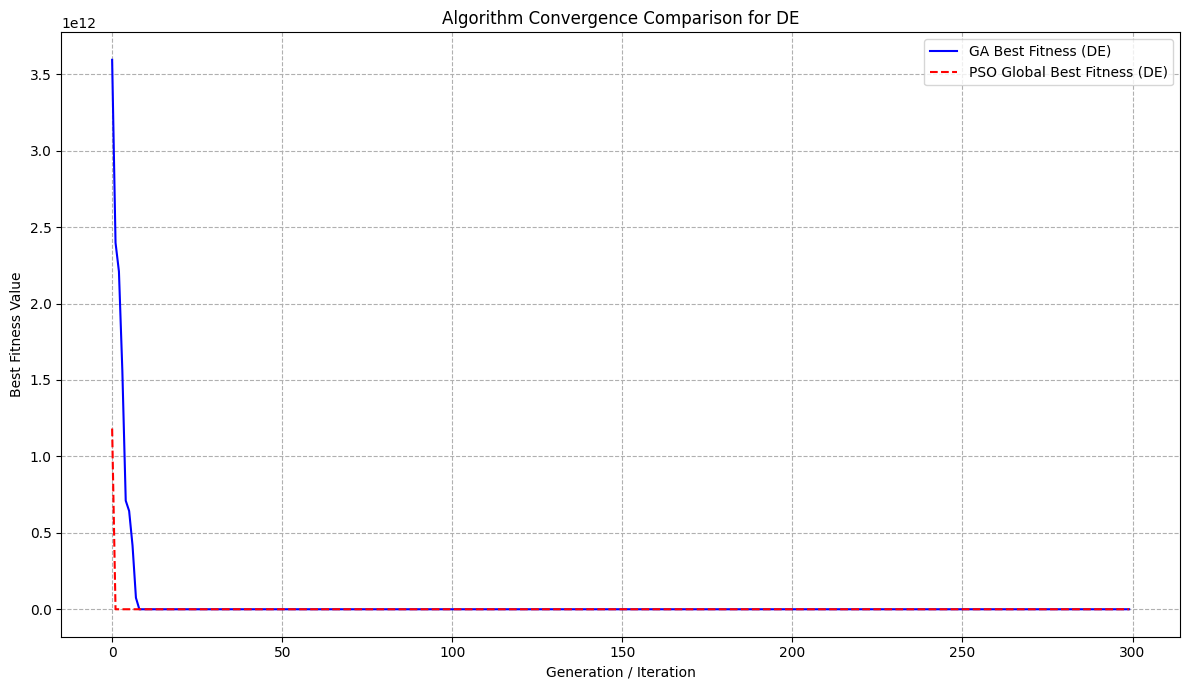



===== STARTING OPTIMIZATION FOR FR =====

Initial Values (FR - 2022):
  x0 (Avg. Electricity Price): 0.2148 Euro/kWh
  y0 (Renewable Share): 0.3527 (35.27%)
  z0 (Total CO2 Emission): 25,539,696 Tonne
  T0 (Total Production): 672,609 GWh
  35 energy source shares found (Battery EXCLUDED).
  Using operating costs for France.
  Fossil fuel sources for FR (for emission calculation): 23 items

Running Genetic Algorithm for FR...
  GA Gen 50/300 - BestFit: 1096404.54 | P: 2.2930 | R%: 68.7 | E: 21.6MT
  GA Gen 100/300 - BestFit: 266073.64 | P: 0.5743 | R%: 58.7 | E: 13.1MT
  GA Gen 150/300 - BestFit: 27457.78 | P: 0.2337 | R%: 42.6 | E: 19.8MT
  GA Gen 200/300 - BestFit: 11953.91 | P: 0.2241 | R%: 39.4 | E: 24.3MT
  GA Gen 250/300 - BestFit: 11911.82 | P: 0.2231 | R%: 39.4 | E: 24.3MT
  GA Gen 300/300 - BestFit: 11911.69 | P: 0.2230 | R%: 39.4 | E: 24.3MT

--- Genetic Algorithm Results (FR) ---
Best Fitness Value: 11911.693896

Best Found Solution (Energy Shares percentage):
Source       

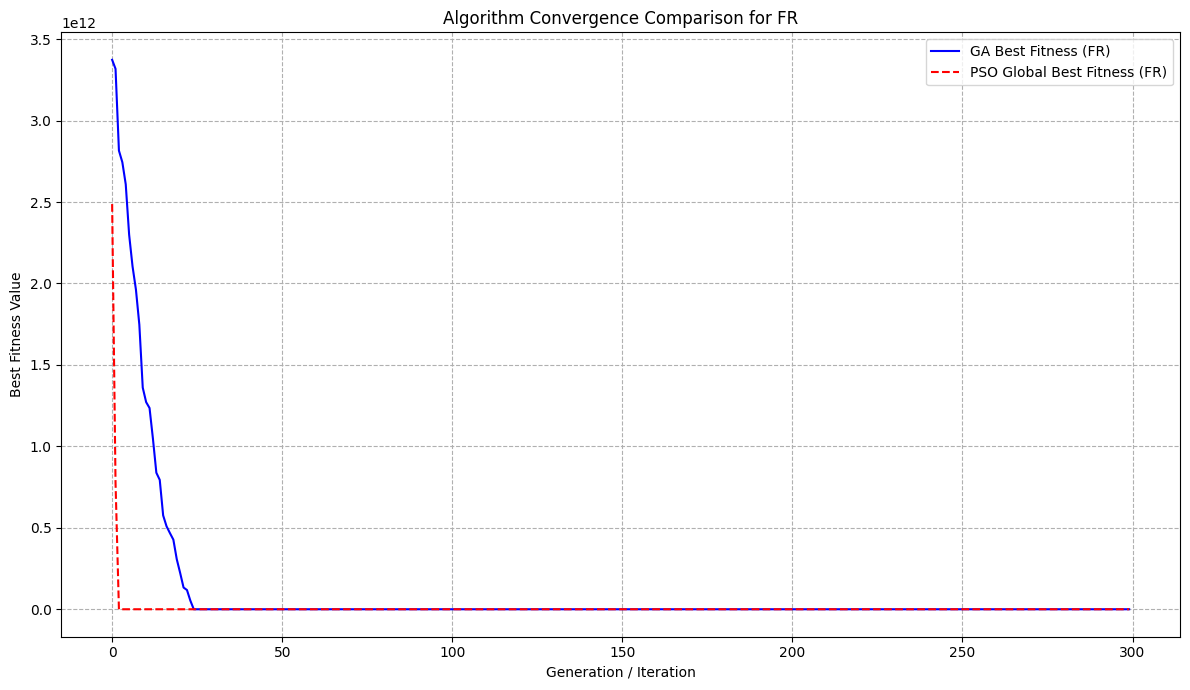

In [14]:
if main_df is not None and 'YEAR' in main_df.columns :
    for country in countries_to_process:
        print(f"\n\n===== STARTING OPTIMIZATION FOR {country} =====")
        country_data_loaded = load_country_data(main_df, country, latest_year)
        if country_data_loaded is None: 
            print(f"Could not load data for {country}, skipping to the next country.")
            continue
            
        x0, y0_actual_ratio, z0, T0, initial_shares, share_columns_list, num_decision_variables_country = country_data_loaded
        
        original_renewable_share_val = main_df[(main_df['country_code'] == country) & (main_df['YEAR'] == latest_year)]['RenewableShare_Percent'].iloc[0]
        initial_shares['RenewableShare_Percent_orig'] = original_renewable_share_val if pd.notna(original_renewable_share_val) else 0.0
        initial_shares['country_code'] = country 
        
        if country == "DE": 
            current_op_costs = unit_costs_euro_per_kwh_DE; current_install_costs = installation_costs_euro_per_kwh_increase_SHARED
            print(f"  Using operating costs for Germany.")
        elif country == "FR": 
            current_op_costs = unit_costs_euro_per_kwh_FR; current_install_costs = installation_costs_euro_per_kwh_increase_SHARED
            print(f"  Using operating costs for France.")
        else: 
            current_op_costs = unit_costs_euro_per_kwh_DE; current_install_costs = installation_costs_euro_per_kwh_increase_SHARED
            print(f"  Warning: Custom cost set not found for {country}, using Germany's costs.")

        for skey in share_columns_list:
            if skey not in current_op_costs: current_op_costs[skey] = default_op_cost
            if skey not in current_install_costs: current_install_costs[skey] = default_install_cost
            
        fossil_sources_country = get_fossil_sources(share_columns_list, renewable_sources_for_y, low_carbon_sources_zero_emission_assumption)
        print(f"  Fossil fuel sources for {country} (for emission calculation): {len(fossil_sources_country)} items")
        
        # Run Genetic Algorithm
        ga_start_time = time.time()
        best_ind_ga, best_fit_ga, best_stats_ga, ga_hist = run_ga(
            initial_shares, x0, y0_actual_ratio, z0, T0, share_columns_list,
            num_decision_variables_country, fossil_sources_country, current_op_costs, current_install_costs
        )
        ga_end_time = time.time()
        print_solution_details("Genetic Algorithm", best_ind_ga, best_fit_ga, best_stats_ga,
                               initial_shares, x0, z0, share_columns_list, y0_actual_ratio)
        print(f"GA Execution Time ({country}): {ga_end_time - ga_start_time:.2f} seconds")
        all_results[f"{country}_GA"] = {"best_individual":best_ind_ga, "stats":best_stats_ga, "history": ga_hist}
        
        # Run Particle Swarm Optimization
        pso_start_time = time.time()
        best_ind_pso, best_fit_pso, best_stats_pso, pso_hist = run_pso(
            initial_shares, x0, y0_actual_ratio, z0, T0, share_columns_list,
            num_decision_variables_country, fossil_sources_country, current_op_costs, current_install_costs
        )
        pso_end_time = time.time()
        print_solution_details("Particle Swarm Opt.", best_ind_pso, best_fit_pso, best_stats_pso,
                               initial_shares, x0, z0, share_columns_list, y0_actual_ratio)
        print(f"PSO Execution Time ({country}): {pso_end_time - pso_start_time:.2f} seconds")
        all_results[f"{country}_PSO"] = {"best_individual":best_ind_pso, "stats":best_stats_pso, "history": pso_hist}
        
        # Plot graph for each country
        if ga_hist and pso_hist: 
             plot_convergence(ga_hist, pso_hist, country)

## 14. Main Execution - Final Summary

In [ ]:
if main_df is not None: 
    end_time_total = time.time()
    print(f"\n\nTotal Execution Time: {end_time_total - start_time_total:.2f} seconds")
    print("\n===== ALL OPTIMIZATIONS COMPLETED =====")
else:
    print("\nScript ended due to data loading issues. No optimizations were run.")